# Cell in BrainCell

This notebook is the direct sequel to `1.morphology.ipynb`.

In the previous tutorial, we focused on geometry and topology. Here we move one layer upward and ask a new question:

**How does a morphology become a simulation-ready cell object?**

We will focus on four ideas:

1. Build a `Cell` directly from an existing morphology.
2. Inspect control volumes (`CV`s), which are the basic structural units of the cell layer.
3. Compare different `cv_policy` choices.
4. Use the declarative APIs `paint(...)` and `place(...)`.

To keep this notebook focused on the cell layer, we will load a ready-made morphology from `./morpho_files/example_tree.swc` instead of rebuilding one by hand.

In [1]:
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")

import matplotlib.pyplot as plt
import brainstate
import brainunit as u
from braincell.morph import Morphology
from braincell._multi_compartment import Cell
from braincell.cv import CVPerBranch, MaxCVLen
from braincell.filter import BranchSlice, RootLocation, at
from braincell.mech import CableProperty, Channel, CurrentClamp, MechanismProbe, StateProbe

ERROR:2026-04-20 09:40:57,141:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 257, in _check_cuda_versions
    cublas_version = _version_check("cuBLAS", cuda_versions.cublas_get_version,
  File "/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 217, in _version_check
    raise RuntimeError(msg)
RuntimeError: Outdated cuBLAS installation found.
Version JAX was built against: 12

## 1. From morphology to `Cell`

A `Cell` starts from a morphology, but it adds an important new layer: **discretization**.

Instead of working directly with whole branches, the cell layer works with **control volumes** (`CV`s). These are the structural units on which cable properties and mechanisms are assigned.

The simplest entry point is therefore:

- load a morphology
- pass it into `Cell(...)`
- inspect the resulting CV structure

In [2]:
morpho = Morphology.from_swc("./morpho_files/example_tree.swc")

print(morpho.topo())

cell = Cell(morpho)
print(cell)

soma
├── axon_0
│   └── axon_1
└── basal_dendrite_0
    ├── basal_dendrite_1
    │   ├── basal_dendrite_2
    │   └── basal_dendrite_3
    ├── basal_dendrite_4
    └── basal_dendrite_5
-----------------------------------
root           | soma
n_branches     | 9
n_cv           | 9
n_paint_rules  | 1
n_place_rules  | 0
-----------------------------------



### Useful `Cell` summary fields

The compact string form of `Cell` shows a few high-level counters.

| Field | Meaning |
| --- | --- |
| `root` | Name of the root branch in the cloned morphology |
| `n_branches` | Total number of morphology branches inside the cell |
| `n_cv` | Total number of control volumes after discretization |
| `n_paint_rules` | Number of recorded `paint(...)` declarations, including the default global cable-property rule |
| `n_place_rules` | Number of recorded `place(...)` declarations |

In [3]:
print("n_cv:", cell.n_cv)
print("len(cell.cvs):", len(cell.cvs))
print("first three CV intervals:")
for cv in cell.cvs[:3]:
    print(f"  CV {cv.id}: branch_id={cv.branch_id}, branch_type={cv.branch_type}, prox={cv.prox}, dist={cv.dist}")

n_cv: 9
len(cell.cvs): 9
first three CV intervals:
  CV 0: branch_id=0, branch_type=soma, prox=0.0, dist=1.0
  CV 1: branch_id=1, branch_type=axon, prox=0.0, dist=1.0
  CV 2: branch_id=2, branch_type=axon, prox=0.0, dist=1.0


## 2. What is a `CV`?

A `CV` (control volume) is the basic structural object in the cell layer.

Conceptually, one CV corresponds to one interval on one branch. It stores:

- geometry, such as length and area
- cable properties, such as `cm`, `ra`, `v`, and `temp`
- topology, such as parent/child CV relationships
- attached mechanisms, split into `density_mech` and `point_mech`

In other words, morphology tells us **where the cable is**, while CVs tell us **where the cell model will actually live**.

### Useful `CV` attributes

| Attribute | Meaning |
| --- | --- |
| `id` | Unique CV index within the cell |
| `branch_id` | Which morphology branch this CV belongs to |
| `branch_type` | The branch type, such as `soma` or `basal_dendrite` |
| `prox` | Proximal boundary of the CV on its branch, in normalized branch coordinates |
| `dist` | Distal boundary of the CV on its branch, in normalized branch coordinates |
| `parent_cv` | Parent CV id, or `None` for the root CV |
| `children_cv` | Child CV ids attached downstream |
| `length` | Physical length of this CV |
| `area` | Membrane area of this CV |
| `cm` | Membrane capacitance density at the CV midpoint |
| `ra` | Axial resistivity at the CV midpoint |
| `v` | Resting / initial membrane potential at the CV midpoint |
| `temp` | Temperature stored at the CV midpoint |
| `r_axial` | Total axial resistance across the CV |
| `r_axial_prox` | Axial resistance from the midpoint to the proximal end |
| `r_axial_dist` | Axial resistance from the midpoint to the distal end |
| `density_mech` | Density mechanisms assigned to this CV |
| `point_mech` | Point mechanisms assigned to this CV |

In [4]:
cv0 = cell.cvs[0]
print(cv0)

# Identity and topology.
print("id:", cv0.id)
print("branch_id:", cv0.branch_id)
print("branch_type:", cv0.branch_type)
print("parent_cv:", cv0.parent_cv)
print("children_cv:", cv0.children_cv)

# Geometry.
print("length:", cv0.length)
print("area:", cv0.area)
print("r_axial:", cv0.r_axial)

# Cable properties defined at the CV midpoint.
print("cm:", cv0.cm)
print("ra:", cv0.ra)
print("v:", cv0.v)
print("temp:", cv0.temp)

# Mechanism containers are empty at this stage.
print("density_mech:", cv0.density_mech)
print("point_mech:", cv0.point_mech)

CV(id=0, branch_id=0, branch_type='soma', prox=0.0, dist=1.0, parent_cv=None, children_cv=(1, 3), length=Quantity(10., "um"), area=Quantity(314.15926536, "um^2"), cm=Quantity(1., "uF / cm^2"), ra=Quantity(100., "cm * ohm"), v=Quantity(-65., "mV"), temp=Quantity(309.15, "K"), r_axial=Quantity(127323.95447352, "ohm"), r_axial_prox=Quantity(63661.97723676, "ohm"), r_axial_dist=Quantity(63661.97723676, "ohm"), density_mech=(), point_mech=(), _frusta=(CVFrustum(prox=0.0, dist=1.0, length=Quantity(10., "um"), radius_prox=Quantity(5., "um"), radius_dist=Quantity(5., "um"), point_prox=Quantity([ 0. -5.  0.], "um"), point_dist=Quantity([0. 5. 0.], "um")),))
id: 0
branch_id: 0
branch_type: soma
parent_cv: None
children_cv: (1, 3)
length: 10. um
area: 314.15926536 um^2
r_axial: 127323.95447352 ohm
cm: 1. uF / cm^2
ra: 100. cm * ohm
v: -65. mV
temp: 309.15 K
density_mech: ()
point_mech: ()


## 3. CV policies

The morphology does not uniquely determine the number of CVs. That job belongs to the **CV policy**.

Three useful cases are:

- `Cell(morpho)`: use the default `CVPerBranch()` policy
- `Cell(morpho, cv_policy=CVPerBranch(cv_per_branch=2))`: force every branch to use two CVs
- `Cell(morpho, cv_policy=MaxCVLen(max_cv_len=...))`: choose the number of CVs automatically from physical branch length

This is the main structural knob of the cell layer.

In [5]:
default_cell = Cell(morpho)
split_cell = Cell(morpho, cv_policy=CVPerBranch(cv_per_branch=2))
auto_cell = Cell(morpho, cv_policy=MaxCVLen(max_cv_len=20.0 * u.um))

print("default policy")
print(default_cell)
print()
print("CVPerBranch(cv_per_branch=2)")
print(split_cell)
print()
print("MaxCVLen(max_cv_len=20 um)")
print(auto_cell)
print()
print("first four CV intervals under CVPerBranch(cv_per_branch=2):")
for cv in split_cell.cvs[:4]:
    print(f"  CV {cv.id}: branch_id={cv.branch_id}, prox={cv.prox}, dist={cv.dist}")

default policy
-----------------------------------
root           | soma
n_branches     | 9
n_cv           | 9
n_paint_rules  | 1
n_place_rules  | 0
-----------------------------------


CVPerBranch(cv_per_branch=2)
-----------------------------------
root           | soma
n_branches     | 9
n_cv           | 18
n_paint_rules  | 1
n_place_rules  | 0
-----------------------------------


MaxCVLen(max_cv_len=20 um)
-----------------------------------
root           | soma
n_branches     | 9
n_cv           | 19
n_paint_rules  | 1
n_place_rules  | 0
-----------------------------------


first four CV intervals under CVPerBranch(cv_per_branch=2):
  CV 0: branch_id=0, prox=0.0, dist=0.5
  CV 1: branch_id=0, prox=0.5, dist=1.0
  CV 2: branch_id=1, prox=0.0, dist=0.5
  CV 3: branch_id=1, prox=0.5, dist=1.0


## 4. The point tree

Besides the CV list, a `Cell` can also expose a **point tree**.

This is the merged point/edge view used by the runtime layer. You can think of it as the execution-oriented representation derived from the CV structure.

For this tutorial, the most important thing is simply to know that:

- `cell.cvs` is the membrane-oriented view
- `cell.point_tree()` is the point/edge execution view

In [6]:
point_tree = split_cell.point_tree()
print(point_tree)
print("n_points:", len(point_tree.points))
print("n_edges:", len(point_tree.edges))
print("expected n_points = n_cv + n_branches + 1:", split_cell.n_cv + len(split_cell.morpho.branches) + 1)

-----------------------------------
n_points       | 28
n_edges        | 27
root_point_id  | 0
-----------------------------------

n_points: 28
n_edges: 27
expected n_points = n_cv + n_branches + 1: 28


## 5. `paint(...)`: declarative region-based assignment

`paint(...)` is the main API for assigning properties or density mechanisms over a region of the cell.

Its general shape is:

- `cell.paint(region, *mechanisms)`

Here:

- `region` is a region expression such as `BranchSlice(...)`
- the remaining arguments are declarative mechanism objects

A useful mental model is that `paint(...)` does not directly run a mechanism. It **declares** what should exist on which part of the cell.

### Painting cable properties

Every `Cell` starts with one default global cable-property rule. A later `paint(...)` call can locally override those midpoint properties on the CVs that fall inside the painted region.

In [7]:
cable_cell = Cell(morpho, cv_policy=CVPerBranch(cv_per_branch=2))
cable_cell.paint(
    BranchSlice(branch_index=0, prox=0.0, dist=1.0),
    CableProperty(
        resting_potential=-70.0 * u.mV,
        membrane_capacitance=2.0 * (u.uF / u.cm**2),
        axial_resistivity=200.0 * (u.ohm * u.cm),
        temperature=u.celsius2kelvin(20.0),
    ),
)

print(cable_cell)
print("painted soma CV example:")
print("v:", cable_cell.cvs[0].v)
print("cm:", cable_cell.cvs[0].cm)
print("ra:", cable_cell.cvs[0].ra)
print("temp:", cable_cell.cvs[0].temp)

-----------------------------------
root           | soma
n_branches     | 9
n_cv           | 18
n_paint_rules  | 2
n_place_rules  | 0
-----------------------------------

painted soma CV example:
v: -70. mV
cm: 2. uF / cm^2
ra: 200. cm * ohm
temp: 293.15 K


### Painting a density mechanism

A density mechanism is distributed over a region rather than attached to a single point.

In the example below, `Channel("IL", ...)` is a declarative channel specification. The cell runtime lowers it into a dense layout over the active CV midpoints.

In [8]:
channel_cell = Cell(morpho)
channel_cell.paint(
    BranchSlice(branch_index=[0, 1], prox=0.0, dist=1.0),
    Channel("IL", g_max=4.0 * (u.mS / u.cm**2), E=-68.0 * u.mV),
)

layout = channel_cell.layouts[0]
point_id = int(layout.point_index[0])

print("layout.kind:", layout.kind)
print("layout.target:", layout.target)
print("layout.n_active:", layout.n_active)
print("layout.source_cv_ids:", layout.source_cv_ids)
print("layout.point_index:", layout.point_index.tolist())
print("sample g_max at one active point:", channel_cell.get_point_state(point_id)[layout.id]["g_max"])
print("sample E at one active point:", channel_cell.get_point_state(point_id)[layout.id]["E"])

layout.kind: channel:IL
layout.target: density
layout.n_active: 2
layout.source_cv_ids: (0, 1)
layout.point_index: [1, 3]
sample g_max at one active point: 4. mS / cm^2
sample E at one active point: -68. mV


## 6. `place(...)`: declarative point mechanisms

`place(...)` is the companion API for mechanisms that should live at a single location instead of over a region.

Its general shape is:

- `cell.place(locset, *mechanisms)`

Here:

- `locset` is a location expression such as `RootLocation(...)`
- the remaining arguments are point mechanisms such as `CurrentClamp`

This is the right API for clamps, probes, and other point-like declarations.

In [9]:
place_cell = Cell(morpho, cv_policy=CVPerBranch(cv_per_branch=2))
place_cell.place(
    RootLocation(x=0.5),
    CurrentClamp.step(0.1 * u.nA, 2.0 * u.ms, delay=1.0 * u.ms),
)

layout = place_cell.layouts[0]

print(place_cell)
print("layout.kind:", layout.kind)
print("layout.target:", layout.target)
print("layout.n_active:", layout.n_active)
print("layout.point_index:", layout.point_index.tolist())
print("amplitudes:", place_cell.get_state(layout.id, "amplitudes"))
print("durations:", place_cell.get_state(layout.id, "durations"))
print("start:", place_cell.get_state(layout.id, "start"))

-----------------------------------
root           | soma
n_branches     | 9
n_cv           | 18
n_paint_rules  | 1
n_place_rules  | 1
-----------------------------------

layout.kind: CurrentClamp
layout.target: point
layout.n_active: 1
layout.point_index: [2]
amplitudes: [(Quantity(0.1, "nA"),)]
durations: [(Quantity(2., "ms"),)]
start: [Quantity(1., "ms")]


## 7. A minimal simulation

So far we have only declared structure and mechanisms. To actually run the cell, we still need two steps:

- call `init_state()` to build runtime state
- run the model over time

Following the style used in the other tutorials, we will use `brainstate.transform.for_loop(...)` to advance the cell through a sequence of time points.

This time we use a simple HH-style configuration:

- passive leak current `IL`
- sodium current `INa_HH1952`
- potassium current `IK_HH1952`
- a point current clamp at the root midpoint

We also make `dt` and `tstop` explicit, because these are the two core time-resolution parameters in a simulation.

current_time after two runs: 20. ms


/tmp/ipykernel_1004271/1910279202.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


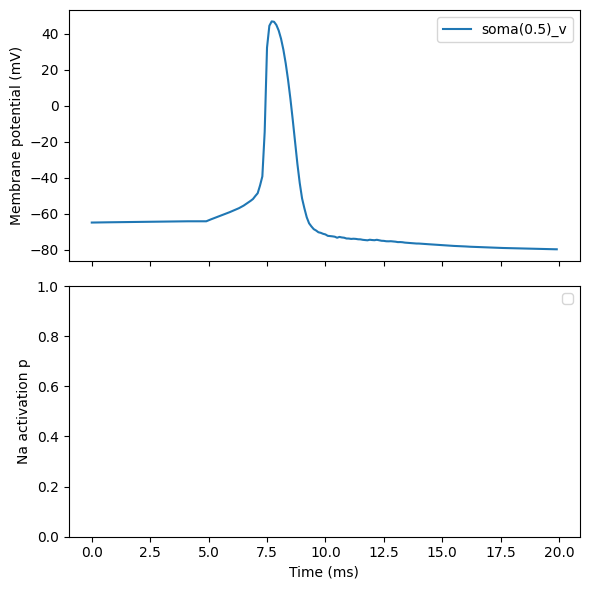

In [16]:
sim_cell = Cell(morpho, cv_policy=CVPerBranch(cv_per_branch=2), solver='staggered')

sim_cell.paint(BranchSlice(branch_index=[0, 1], prox=0.0, dist=1.0), 
               Channel("IL", g_max=0.03 * (u.mS / u.cm**2), E=-54.387 * u.mV),
               Channel("Nav1p6_MA24_PC", g_max=120.0 * (u.mS / u.cm**2)),
               Channel("IK_HH1952", g_max=36.0 * (u.mS / u.cm**2))
               )

sim_cell.place(
    RootLocation(x=0.5),
    CurrentClamp.step(0.1 * u.nA, 5.0 * u.ms, delay=5.0 * u.ms),
)

sim_cell.place(
    at("soma", 0.5),
    StateProbe(),
    # MechanismProbe(mechanism="INa_HH1952", field="p"),
)

sim_cell.init_state()

dt = 0.1 * u.ms
duration = 10.0 * u.ms

result1 = sim_cell.run(dt=dt, duration=duration)
result2 = sim_cell.run(dt=dt, duration=duration)

times_ms = u.math.concatenate([
    result1.time.to_decimal(u.ms),
    result2.time.to_decimal(u.ms),
])
vs_mV = u.math.concatenate([
    result1.traces["soma(0.5)_v"].to_decimal(u.mV),
    result2.traces["soma(0.5)_v"].to_decimal(u.mV),
])
# na_p = u.math.concatenate([
#     result1.traces["soma(0.5)_INa_HH1952_p"],
#     result2.traces["soma(0.5)_INa_HH1952_p"],
# ])

print("current_time after two runs:", sim_cell.current_time)

fig, axes = plt.subplots(2, 1, figsize=(6, 6), sharex=True)
axes[0].plot(times_ms, vs_mV, label="soma(0.5)_v")
axes[0].set_ylabel("Membrane potential (mV)")
axes[0].legend()

#axes[1].plot(times_ms, na_p, label="soma(0.5)_INa_HH1952_p", color="tab:orange")
axes[1].set_xlabel("Time (ms)")
axes[1].set_ylabel("Na activation p")
axes[1].legend()

plt.tight_layout()
plt.show()

## Summary

You have now seen the main ideas of the cell layer in BrainCell:

- Start from an existing morphology and build a `Cell`.
- Inspect the resulting `CV`s.
- Change discretization through `cv_policy`.
- Understand the point tree as the execution-oriented structural view.
- Use `paint(...)` for region-based declarations.
- Use `place(...)` for point mechanisms.

A natural next step is `/home/swl/braincell/examples/multi_compartment/3.vis.ipynb`, where the structural and runtime views become easier to inspect visually.